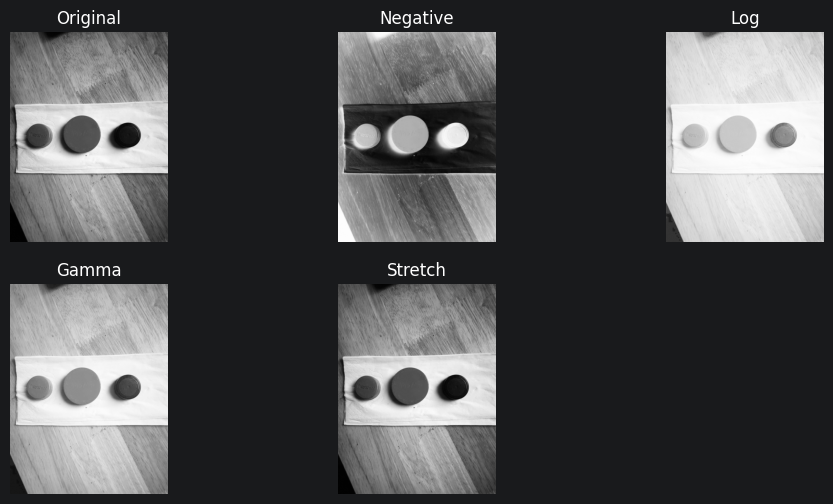

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# đọc ảnh grayscale
img = cv2.imread('./img_data/anhnaptrai.jpg', 0)


# 1. NEGATIVE

neg = 255 - img


# 2. LOG TRANSFORM
# s = c * log(1 + r)

c = 255 / np.log(1 + np.max(img))
log_img = c * np.log(1 + img)
log_img = np.array(log_img, dtype=np.uint8)


# 3. GAMMA TRANSFORM
# s = c * r^gamma

gamma = 0.5   # <1: sáng lên, >1: tối đi
gamma_img = np.power(img / 255.0, gamma) * 255
gamma_img = np.array(gamma_img, dtype=np.uint8)


# 4. CONTRAST STRETCHING

r_min = np.min(img)
r_max = np.max(img)

stretch = (img - r_min) * (255 / (r_max - r_min))
stretch = np.array(stretch, dtype=np.uint8)


# HIỂN THỊ

titles = ['Original', 'Negative', 'Log', 'Gamma', 'Stretch']
images = [img, neg, log_img, gamma_img, stretch]

plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

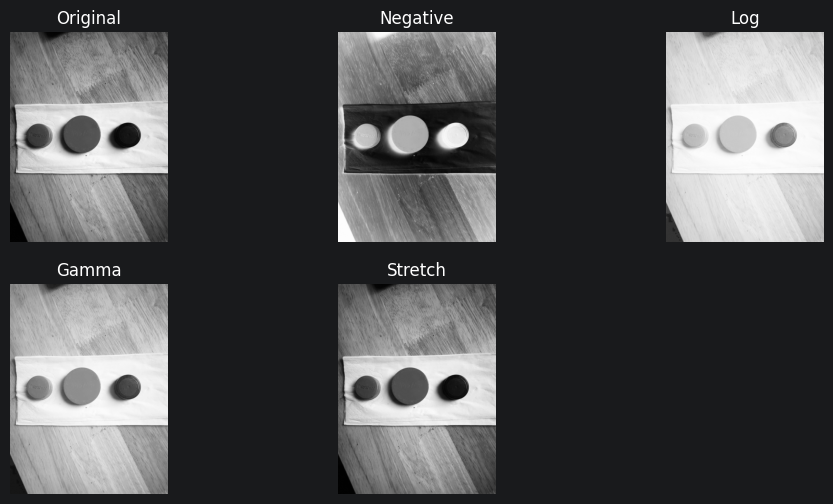

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('./img_data/anhnaptrai.jpg', 0)


# 1. NEGATIVE (dùng bitwise_not)

neg = cv2.bitwise_not(img)


# 2. LOG TRANSFORM (vẫn phải tự viết vì OpenCV không có sẵn)

c = 255 / np.log(1 + np.max(img))
log_img = c * np.log(1 + img)
log_img = np.array(log_img, dtype=np.uint8)

# 3. GAMMA (dùng LUT)

gamma = 0.5
table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype("uint8")
gamma_img = cv2.LUT(img, table)


# 4. CONTRAST STRETCH (normalize)

stretch = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)


# HIỂN THỊ
titles = ['Original', 'Negative', 'Log', 'Gamma', 'Stretch']
images = [img, neg, log_img, gamma_img, stretch]

plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()